# DSCI235 Final Project
**Stella Kaulbach** and **Tucker Sussenbach**

// put a github link in???



### Introduction

For this project, we are going to be analyzing a portion of the 2022 Environmental Performance Index (EPI) report which ranks 180 countries on various performance indicators related to environmental health, ecosystem vitality, and climate change. We will focus on the environmental health data, which includes 13 performance indicators specifically focused on quantifying the air quality, sanitation and drinking water, heavy metal (lead) exposure, and waste management of each country over time For each indicator. Each indicator is a score from 0-100 on how that country performed on that particular metric. The scores were generated by the University of Columbia based on applying specific transformations to each metric; for more information, see the Technical Appendix in the repository. 

This data is publicly available in the [EARTHDATA](https://www.earthdata.nasa.gov/) website, which is the portal for the Earth Science Data Systems (ESDS) Program, providing open access to NASA’s archive of Earth science data. Throuhgout this report, we will make use of the information provided in the Technical Appendix, included when you download the data. We have included this pdf in the files on the github repository under the name "2022-epi-technical-appendix.pdf". 

The structure of the data is as follows: there are 13 CSV files, each one focusing on a particular performance indicator for environmental health. A CSV file for a given performance indicator contains a country’s name, ISO code (both the 3 digit abbreviation and the number), and the EPI score for that country for the given performance indicator for years between 1995 and 2022 (inclusive). The way that the data is compiled allows for comparisons of a country over time and countries with each other. 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Data Organization and Cleaning

For our main data structure, we chose to use a MultiIndex dataframe to hold all our datapoints. The MultiIndex allows us to access our data in several different manners, making it very easy to do analysis by country, year, or indicator (or a combination of those). Thus, we have `all_data`, which holds every datapoint and can be indexed in several different ways. 

In [6]:
indicators = ["PMD", "HAD", "OZD", "NOE", "SOE", "COE", "VOE", "USD", "UWD", "PBD", "MSW", "REC", "OCP"]
datasets = []

for x in indicators:
    x_init = pd.read_csv("HLT\\"+x+"_ind_na.csv")
    
    x_long = x_init.melt(id_vars=["code", "iso", "country"], var_name="indicator_year", value_name="value") 
    
    x_long["indicator"] = x
    x_long["year"] = x_long["indicator_year"].str[-4:].astype(int)
    
    x_long = x_long.drop(columns=["indicator_year"])
    
    datasets.append(x_long)
    
all_data = pd.concat(datasets, ignore_index=True)

all_data = all_data.set_index(["code", "iso", "year", "indicator"]).sort_index()

all_data

country      value
code iso year indicator                        
4    AFG 1995 COE        Afghanistan  46.499051
              HAD        Afghanistan   0.000000
              MSW        Afghanistan   1.060000
              NOE        Afghanistan  45.528483
              OCP        Afghanistan        NaN
...                              ...        ...
894  ZMB 2022 REC             Zambia  12.630000
              SOE             Zambia  43.907576
              USD             Zambia  13.924561
              UWD             Zambia  13.248474
              VOE             Zambia  12.812337

[80080 rows x 2 columns]

We also felt that it would be necessary to search for the numeric code associated with each country, so we created `iso_dict` is a dictionary that holds the name of each country as the key and then its corresponding numeric code as a value.

In [7]:
iso_dict = all_data["country"].droplevel(("year", "indicator"))
iso_dict = iso_dict.reorder_levels(["code", "iso"]).index
iso_dict = dict(zip(all_data["country"], iso_dict.get_level_values("code")))
iso_dict

{'Afghanistan': 4,
 'Albania': 8,
 'Algeria': 12,
 'Andorra': 20,
 'Angola': 24,
 'Antigua and Barbuda': 28,
 'Azerbaijan': 31,
 'Argentina': 32,
 'Australia': 36,
 'Austria': 40,
 'Bahamas': 44,
 'Bahrain': 48,
 'Bangladesh': 50,
 'Armenia': 51,
 'Barbados': 52,
 'Belgium': 56,
 'Bermuda': 60,
 'Bhutan': 64,
 'Bolivia': 68,
 'Bosnia and Herzegovina': 70,
 'Botswana': 72,
 'Brazil': 76,
 'Belize': 84,
 'Solomon Islands': 90,
 'British Virgin Islands': 92,
 'Brunei Darussalam': 96,
 'Bulgaria': 100,
 'Myanmar': 104,
 'Burundi': 108,
 'Belarus': 112,
 'Cambodia': 116,
 'Cameroon': 120,
 'Canada': 124,
 'Cabo Verde': 132,
 'Cayman Islands': 136,
 'Central African Republic': 140,
 'Sri Lanka': 144,
 'Chad': 148,
 'Chile': 152,
 'China': 156,
 'Taiwan': 158,
 'Colombia': 170,
 'Comoros': 174,
 'Republic of Congo': 178,
 'Dem. Rep. Congo': 180,
 'Cook Islands': 184,
 'Costa Rica': 188,
 'Croatia': 191,
 'Cuba': 192,
 'Cyprus': 196,
 'Czech Republic': 203,
 'Benin': 204,
 'Denmark': 208,
 'Do

In the Technical Appendix, each indicator is given a weight which represents the significance of that particular metric to the category that it is in. For example, the PMD indicator (PM<sub>2.5</sub> Exposure) is given a 47% weight, which means that it is 47% of the AIR (Air Quality) category. Since we eventually want to have a single score that measures overall Environmental Health (HTL) of a given country, we need to get the weights of each performance indicator in terms of the overall category HLT. 

The below image comes directly from page 3 of the Technical Appendix, and serves as a reference of where the numbers in `weight_indiv` and `weight_group` come from. 

![Subsection of Table from page 3 of Technical Appendix](HLT_Weights.png)

Thus, we multiplied each individual weight (value in `weight_indiv`) by the weight of that category (value in `weight_group`), and then had to do a bit of normalizing to make sure that all the final weights summed to 1. The result is `weight`, which holds a value representing the significance of each performance indicator to the overall category of Environmental Health. 

In [8]:
weight_indiv = pd.Series({"PMD": 0.47, "HAD": 0.38, "OZD": 0.05, "NOE": 0.05, "SOE": 0.02, "COE": 0.02, "VOE": 0.02, "USD": 0.40, "UWD":0.60, "PBD": 1.00, "MSW": 0.50, "REC": 0.25, "OCP": 0.25})
weight_group = pd.Series({"PMD": 0.55, "HAD": 0.55, "OZD": 0.55, "NOE": 0.55, "SOE": 0.55, "COE": 0.55, "VOE": 0.55, "USD": 0.25, "UWD":0.25, "PBD": 0.10, "MSW": 0.10, "REC": 0.10, "OCP": 0.10})

weight = weight_indiv * weight_group
weight /= weight.sum()
weight

PMD    0.257086
HAD    0.207857
OZD    0.027350
NOE    0.027350
SOE    0.010940
COE    0.010940
VOE    0.010940
USD    0.099453
UWD    0.149180
PBD    0.099453
MSW    0.049727
REC    0.024863
OCP    0.024863
dtype: float64

Now that we have the weights, we need to add the weights onto the dataframe for future weighted average computaions.

*We created a new dataframe so the original dataframe is unaffected*

In [9]:
weighted_data = all_data.copy()
weighted_data['weight'] = weighted_data.index.get_level_values('indicator').map(weight)
weighted_data['weighted_value'] = weighted_data['value'] * weighted_data['weight']
weighted_data.head()

country      value    weight  weighted_value
code iso year indicator                                                  
4    AFG 1995 COE        Afghanistan  46.499051  0.010940        0.508692
              HAD        Afghanistan   0.000000  0.207857        0.000000
              MSW        Afghanistan   1.060000  0.049727        0.052710
              NOE        Afghanistan  45.528483  0.027350        1.245185
              OCP        Afghanistan        NaN  0.024863             NaN

In order to get a single rating for each country for a given year, we needed to take the weighted average of all the performance indicators using the weights from above. This will give us a single value from 0 - 100 that quatifies the overall environmental health for a country in a given year.

However, not all country has ratings for all 13 indicators, so we need to make sure that our average calculations are accounting for the missing data. To do this, we also keep track of the sum of the weights, and then normalize the averages using their weight sums.

In [10]:
temp_df = weighted_data.dropna(subset=['weighted_value', 'weight']).groupby(level=['code','year']).agg(weighted_sum=('weighted_value', 'sum'), weight_sum=('weight', 'sum'))
temp_df['weighted_avg'] = temp_df['weighted_sum'] / temp_df['weight_sum']
temp_df

weighted_sum  weight_sum  weighted_avg
code year                                        
4    1995     15.250911    0.975137     15.639766
     1996     15.332889    0.975137     15.723835
     1997     15.055237    0.975137     15.439104
     1998     14.846390    0.975137     15.224931
     1999     14.676584    0.975137     15.050795
...                 ...         ...           ...
894  2018     20.816443    0.975137     21.347204
     2019     21.165970    0.975137     21.705643
     2020     21.171291    0.975137     21.711100
     2021     21.171291    0.975137     21.711100
     2022     21.171291    0.975137     21.711100

[6160 rows x 3 columns]

Now that we have our weighted averages, we would like to combine this with parts of original dataframe to have `code` and `country` values also accessible in the same data structure as the weighted averages. 

In [31]:
# doa a choin
weighted_avgs = all_data.droplevel('indicator')
weighted_avgs.drop('value', axis=1, inplace=True)
weighted_avgs = weighted_avgs.join(temp_df, how = "outer")
weighted_avgs.drop(columns=['weighted_sum', 'weight_sum'], inplace=True)
weighted_avgs["year"] = weighted_avgs.index.get_level_values("year")
weighted_avgs.drop_duplicates(inplace=True)
weighted_avgs.drop("year", axis = 1, inplace=True)
weighted_avgs

country  weighted_avg
code iso year                           
4    AFG 1995  Afghanistan     15.639766
         1996  Afghanistan     15.723835
         1997  Afghanistan     15.439104
         1998  Afghanistan     15.224931
         1999  Afghanistan     15.050795
...                    ...           ...
894  ZMB 2018       Zambia     21.347204
         2019       Zambia     21.705643
         2020       Zambia     21.711100
         2021       Zambia     21.711100
         2022       Zambia     21.711100

[6160 rows x 2 columns]

Beyond just the weighted average, we also wanted to quantify the overall change the each country has overgone for all the years where data is available. So, we found a rate of change for the weighted averages by taking the difference of most recent year and the oldest year and then dividing by the number of years. 

This information allows us to quantify overall improvement in environmental health over time.

In [69]:
# Find total difference for each county and divide by years to get the rate
def total_diff(country):
    country["total_diff_rate"] = ((country.iloc[-1].weighted_avg) - (country.iloc[0].weighted_avg)) / len(country)
    return country

weighted_avgs_2 = weighted_avgs.groupby('code').apply(total_diff)
weighted_avgs = weighted_avgs_2.droplevel(0)
weighted_avgs

country  weighted_avg  total_diff_rate
code iso year                                            
4    AFG 1995  Afghanistan     15.639766         0.029028
         1996  Afghanistan     15.723835         0.029028
         1997  Afghanistan     15.439104         0.029028
         1998  Afghanistan     15.224931         0.029028
         1999  Afghanistan     15.050795         0.029028
...                    ...           ...              ...
894  ZMB 2018       Zambia     21.347204         0.108386
         2019       Zambia     21.705643         0.108386
         2020       Zambia     21.711100         0.108386
         2021       Zambia     21.711100         0.108386
         2022       Zambia     21.711100         0.108386

[6160 rows x 3 columns]

Explain getting best and worst for weighted avg

In [95]:
sorted_avgs = weighted_avgs.sort_values(by = "weighted_avg")
sorted_avgs.head(10), sorted_avgs.tail(10)


(               country  weighted_avg  total_diff_rate
 code iso year                                        
 356  IND 1998    India      7.748112         0.152754
          1997    India      7.792811         0.152754
          1999    India      7.989086         0.152754
          2000    India      8.083913         0.152754
          2001    India      8.188146         0.152754
          1995    India      8.191865         0.152754
          1996    India      8.216341         0.152754
          2002    India      8.388171         0.152754
          2003    India      8.782292         0.152754
 426  LSO 2013  Lesotho      8.983694        -0.126526,
                country  weighted_avg  total_diff_rate
 code iso year                                        
 246  FIN 2017  Finland     93.139378         0.593317
 352  ISL 2014  Iceland     93.305664         0.480516
          2015  Iceland     93.696851         0.480516
          2016  Iceland     93.708201         0.480516
         

Analysis of best and worst weighted avgs

Text(0, 0.5, 'Number of Countries')

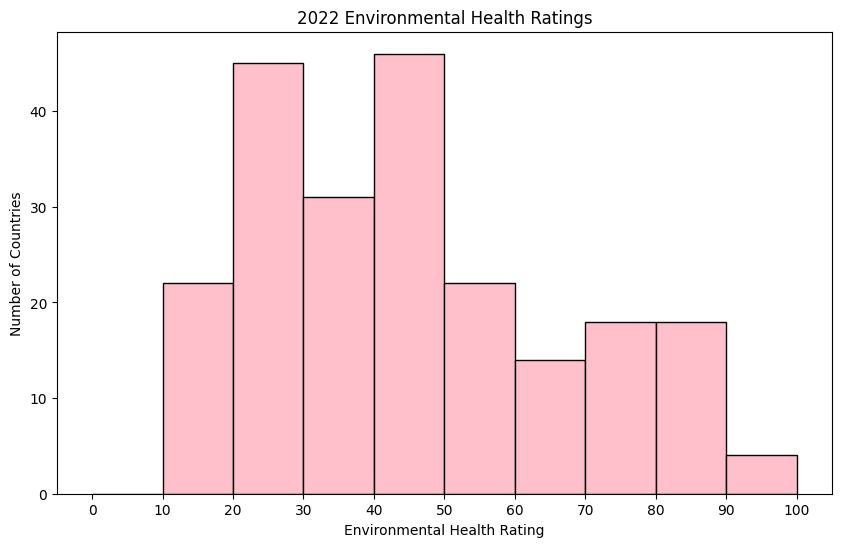

In [79]:
# Plot the rate of each country
most_recent_avgs = weighted_avgs.droplevel("iso").reorder_levels(["year", "code"]).loc[2022]

fig, ax = plt.subplots(figsize = (10, 6))

ax.hist(most_recent_avgs["weighted_avg"], bins = np.linspace(0, 100, 11), color = "pink", edgecolor = "black")
ax.set_xticks(np.linspace(0, 100, 11))
ax.set_title("2022 Environmental Health Ratings")
ax.set_xlabel("Environmental Health Rating")
ax.set_ylabel("Number of Countries")

analysis of graph

We also want to look at a scatterplot of weighted averages and total changes

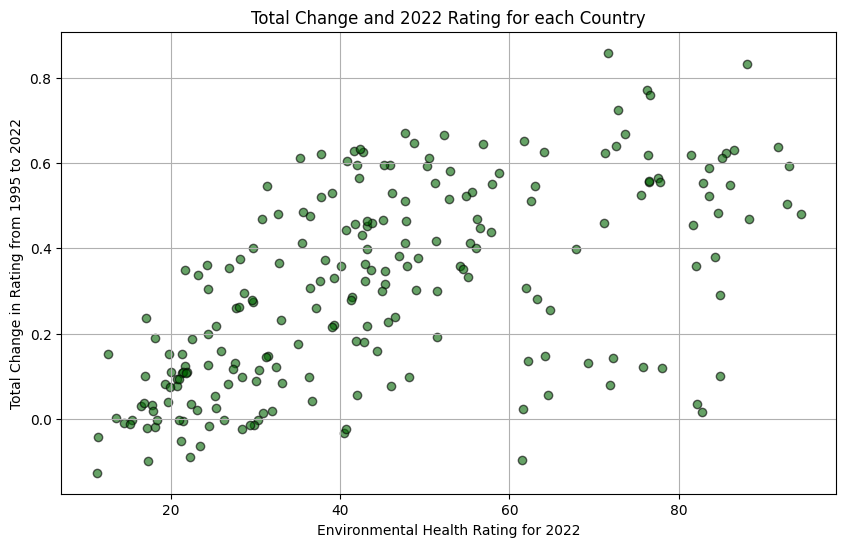

In [93]:
fig, ax = plt.subplots(figsize = (10, 6))

ax.scatter(most_recent_avgs["weighted_avg"], most_recent_avgs["total_diff_rate"], color = "darkgreen", edgecolors="black", alpha=.60)

ax.set_xlabel("Environmental Health Rating for 2022")
ax.set_ylabel("Total Change in Rating from 1995 to 2022")
ax.set_title("Total Change and 2022 Rating for each Country")

ax.grid(visible=True)

analysis of graph

In [34]:
# Find difference from start-2015 and 2015-end for paris and divide by #years to get rate
def before_diff(country):
    idx = pd.IndexSlice
    years = country.index.get_level_values(-1)
    years_before = (years < 2015).sum()
    country["before_PCA_diff"] = ((country.loc[idx[:,:,2015]].weighted_avg) - (country.iloc[0].weighted_avg)) / years_before
    return country

def after_diff(country):
    idx = pd.IndexSlice
    years = country.index.get_level_values(-1)
    years_after = (years > 2015).sum()
    country["after_PCA_diff"] = ((country.iloc[-1].weighted_avg) - (country.loc[idx[:,:,2015]].weighted_avg)) / years_after
    return country


temp_diff = weighted_avgs.groupby('code').apply(before_diff).droplevel(0)
paris_diff2 = temp_diff.groupby('code').apply(after_diff)
paris_diff = paris_diff2.droplevel(0)
paris_diff

country  weighted_avg  total_diff_rate  before_PCA_diff  \
code iso year                                                                
4    AFG 1995  Afghanistan     15.639766         0.029028        -0.005395   
         1996  Afghanistan     15.723835         0.029028        -0.005395   
         1997  Afghanistan     15.439104         0.029028        -0.005395   
         1998  Afghanistan     15.224931         0.029028        -0.005395   
         1999  Afghanistan     15.050795         0.029028        -0.005395   
...                    ...           ...              ...              ...   
894  ZMB 2018       Zambia     21.347204         0.108386         0.070994   
         2019       Zambia     21.705643         0.108386         0.070994   
         2020       Zambia     21.711100         0.108386         0.070994   
         2021       Zambia     21.711100         0.108386         0.070994   
         2022       Zambia     21.711100         0.108386         0.070994   

               after_PCA_diff  
code iso year                  
4    AFG 1995        0.131526  
         1996        0.131526  
         1997        0.131526  
         1998        0.131526  
         1999        0.131526  
...                       ...  
894  ZMB 2018        0.230705  
         2019        0.230705  
         2020        0.230705  
         2021        0.230705  
         2022        0.230705  

[6160 rows x 5 columns]

In [62]:
# Find the difference between those two rate and look for changes

In [63]:
# Plot the diff and see if the Paris CA did anything

In our initial datasets, each performance indicator includes data for every year from 1995 to 2022 for 220 countries, resulting in a total of around 6,000 intial datapoints. We felt that this was a bit too much to work with, so we decided to streamline our data by only including certain years. By selecting certain years, we can keep our data at a manageable size while still having data that can be used to interpret the changes in each country over time and to analyze the impact that particular events had on these performance indicators. So, we selected 7 different years that span from the late 1990s to the 2020s, each one containing a climate change-related event. 


The years are as follows:

2022 - most recent data availiable

2019 - The UK passes laws that commit to reducing greenhouse gas emissions to net zero by 2050. 

2015 - 196 countries sign up to the Paris Climate Agreement

2008 - The UK Climate Change Act is enshrined in law

2005 - Kyoto Protocol Enters Into Force (The Kyoto Protocol was an international treaty that committed industrialized nations to reduce greenhouse gas emissions.)

1996 - The world’s first carbon storage project gets underway (Carbon storage involves ____________________)

id like to add more to this text ^

In [64]:
years = [1996, 2005, 2008, 2015, 2019, 2022]

### Data Exploration and Analysis

Graphic of US DALY indicators over time


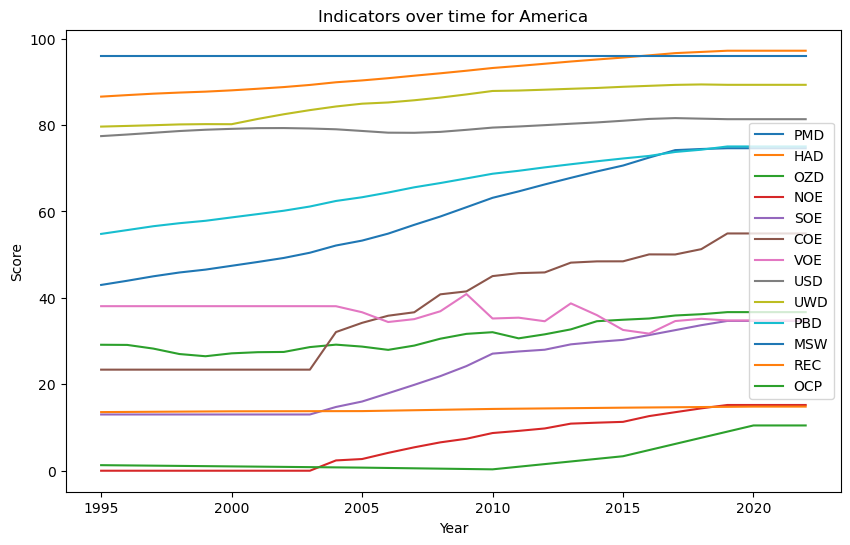

In [66]:
# get the numeric iso code for USA
USA_num = iso_dict.get("United States of America")
USA_data = all_data.loc[USA_num].value


plt.figure(figsize=(10, 6))
for p_i in indicators:
    plt.plot(USA_data.droplevel("iso").reorder_levels(["indicator", "year"]).loc[p_i], label = p_i)


plt.xlabel("Year")
#plt.xticks(years)
plt.ylabel("Score")
plt.title("Indicators over time for America") #Disability-Adjusted Life Years per 100,000 people measure the total health burden, including years of life lost to premature death and years lived with disability, adjusted for population age differences
plt.legend()

Do another graph like this ^ for the one with the most change overall

### Conclusion